In [1]:
# Importing Libraries
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) #clean up the skilllist to a list datatype

## 1

Text(0.5, 1.0, 'Proportion of Data Analyst Jobs Mentioning Health Insurance')

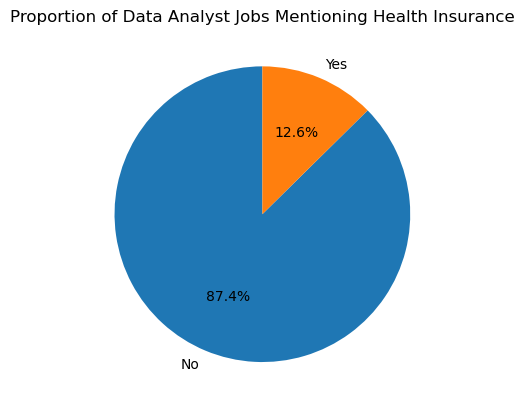

In [2]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
count = df_DA['job_health_insurance'].value_counts()
plt.pie(count, labels=['No', 'Yes'], startangle=90, autopct='%1.1f%%')
plt.title('Proportion of Data Analyst Jobs Mentioning Health Insurance')

## 2

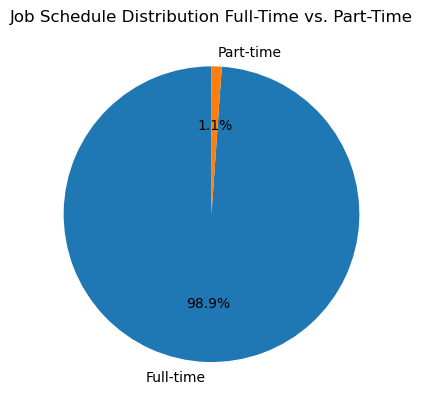

In [7]:
df_ft_pt = df[(df['job_schedule_type'] == 'Full-time') | (df['job_schedule_type'] == 'Part-time')].copy()                 
count = df_ft_pt['job_schedule_type'].value_counts()
plt.pie(count, labels=count.index, startangle=90, autopct='%1.1f%%')
plt.title('Job Schedule Distribution Full-Time vs. Part-Time')
plt.show()

## 3

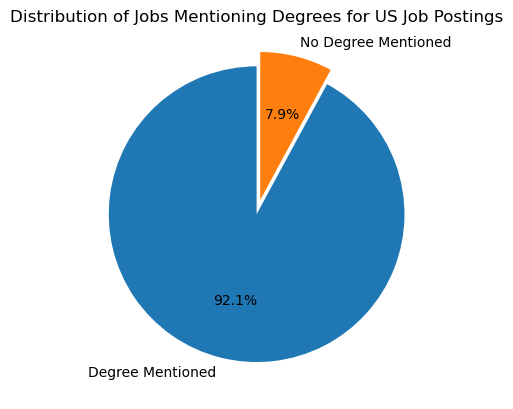

In [12]:
df_US = df[df['job_location'] == 'United States'].copy()
degree_counts = df_US['job_no_degree_mention'].value_counts()
plt.pie(degree_counts, labels=['Degree Mentioned', 'No Degree Mentioned'], autopct='%1.1f%%', startangle=90, explode=(0, 0.1))
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()